# Musical Two Sum - Pair with given Interval
## Finding harmonic pairs using 4 different algorithms with Music21

### Problem Conversion

**Original Problem:** Find two numbers in an array that sum to a target value

**Musical Problem:** Find two notes in a melody that create a target musical interval (in semitones)

**Mapping:**
- Array of integers → Array of MIDI note numbers
- Target sum → Target interval (semitones)
- Example: MIDI [60, 62, 64, 67] with target 7 = C4 + G4 (Perfect Fifth!)

In [ ]:
# Install music21 if needed
# !pip install music21

from music21 import note, stream, chord
import time

print("✅ Libraries loaded successfully!")

## Approach 1: Brute Force (Nested Loops)
**Time:** O(n²) - nested loops check all pairs  
**Space:** O(1) - only using a constant amount of variables

Check every possible pair of notes to find the target interval

In [2]:
def musical_two_sum_bruteforce(midi_notes, target_interval):
    """
    Brute Force: Check every possible pair
    Musical: Listen to all possible harmonies
    """
    n = len(midi_notes)
    
    for i in range(n):
        for j in range(i+1, n):  # Start inner loop at i+1
            interval = abs(midi_notes[j] - midi_notes[i])
            if interval == target_interval:
                return True  # Found the pair!
    
    return False

# Test cases
arr1 = [60, 62, 64, 67]  # C4, D4, E4, G4
target1 = 7  # Perfect Fifth
print(f"Brute Force Test 1: {musical_two_sum_bruteforce(arr1, target1)}  # Expected: True")

arr2 = [60, 61, 62]  # C4, C#4, D4
target2 = 6  # Tritone (not present)
print(f"Brute Force Test 2: {musical_two_sum_bruteforce(arr2, target2)}  # Expected: False")

Brute Force Test 1: True  # Expected: True
Brute Force Test 2: False  # Expected: False


### Visualize the Brute Force Approach

In [3]:
def musical_two_sum_bruteforce_detailed(midi_notes, target_interval):
    """Brute force with visualization"""
    n = len(midi_notes)
    
    # Display the notes
    print(f"Notes: {midi_notes}")
    print(f"Target interval: {target_interval} semitones\n")
    
    s = stream.Stream()
    for midi_num in midi_notes:
        s.append(note.Note(midi=midi_num))
    print("Musical notation:")
    s.show('text')
    
    print(f"\nChecking all {n * (n-1) // 2} possible pairs:\n")
    
    for i in range(n):
        for j in range(i+1, n):
            interval = abs(midi_notes[j] - midi_notes[i])
            note1 = note.Note(midi=midi_notes[i])
            note2 = note.Note(midi=midi_notes[j])
            
            print(f"  {note1.nameWithOctave} + {note2.nameWithOctave} → {interval} semitones", end="")
            
            if interval == target_interval:
                print(" ✅ MATCH!")
                c = chord.Chord([midi_notes[i], midi_notes[j]])
                result = stream.Stream()
                result.append(c)
                print(f"\nFound as chord:")
                result.show('text')
                return True
            else:
                print()
    
    print(f"\n❌ No pair found")
    return False

print("=" * 60)
print("EXAMPLE 1: Brute Force")
print("=" * 60)
musical_two_sum_bruteforce_detailed([60, 62, 64, 67], 7)

EXAMPLE 1: Brute Force
Notes: [60, 62, 64, 67]
Target interval: 7 semitones

Musical notation:
{0.0} <music21.note.Note C>
{1.0} <music21.note.Note D>
{2.0} <music21.note.Note E>
{3.0} <music21.note.Note G>

Checking all 6 possible pairs:

  C4 + D4 → 2 semitones
  C4 + E4 → 4 semitones
  C4 + G4 → 7 semitones ✅ MATCH!

Found as chord:
{0.0} <music21.chord.Chord C4 G4>


True

## Approach 2: Sort + Binary Search
**Time:** O(n log n) - sorting dominates  
**Space:** O(1) - not counting the sorted array

Sort the notes, then for each note, binary search for its complement

In [4]:
def binary_search_note(arr, target, start_index):
    """Binary search to find a target note"""
    left = start_index
    right = len(arr) - 1
    
    while left <= right:
        mid = (left + right) // 2
        if arr[mid] == target:
            return (True, mid)
        elif target < arr[mid]:
            right = mid - 1  # Search left half
        else:
            left = mid + 1   # Search right half
    
    return (False, None)

In [5]:
def musical_two_sum_binarysearch(midi_notes, target_interval):
    """
    Sort + Binary Search: Sort notes, then binary search for complement
    Musical: Organize by pitch, then search systematically
    """
    sorted_notes = sorted(midi_notes)
    
    for i in range(len(sorted_notes)):
        # Search for both possible complements
        complement_higher = sorted_notes[i] + target_interval
        complement_lower = sorted_notes[i] - target_interval
        
        (found_higher, idx_higher) = binary_search_note(sorted_notes, complement_higher, i + 1)
        (found_lower, idx_lower) = binary_search_note(sorted_notes, complement_lower, 0)
        
        if found_higher and idx_higher != i:
            return True
        if found_lower and idx_lower != i:
            return True
    
    return False

# Test cases
arr1 = [60, 62, 64, 67]  # C4, D4, E4, G4
print(f"Binary Search Test 1: {musical_two_sum_binarysearch(arr1, 7)}  # Expected: True")

arr2 = [60, 61, 62]  # C4, C#4, D4
print(f"Binary Search Test 2: {musical_two_sum_binarysearch(arr2, 6)}  # Expected: False")

Binary Search Test 1: True  # Expected: True
Binary Search Test 2: False  # Expected: False


## Approach 3: Sort + Two Pointers
**Time:** O(n log n) - sorting dominates  
**Space:** O(1) - only using pointers

Sort notes and converge from both ends using two pointers

In [6]:
def musical_two_sum_twopointers(midi_notes, target_interval):
    """
    Sort + Two Pointers: Move from both ends towards middle
    Musical: Like two hands on a piano finding the perfect interval
    """
    sorted_notes = sorted(midi_notes)
    left = 0
    right = len(sorted_notes) - 1
    
    while left < right:
        interval = sorted_notes[right] - sorted_notes[left]
        
        if interval == target_interval:
            return True  # Found the pair!
        elif interval < target_interval:
            left += 1    # Need larger interval, move left right
        else:
            right -= 1   # Need smaller interval, move right left
    
    return False

# Test cases
arr1 = [60, 62, 64, 67]  # C4, D4, E4, G4
print(f"Two Pointers Test 1: {musical_two_sum_twopointers(arr1, 7)}  # Expected: True")

arr2 = [60, 61, 62]  # C4, C#4, D4
print(f"Two Pointers Test 2: {musical_two_sum_twopointers(arr2, 6)}  # Expected: False")

Two Pointers Test 1: True  # Expected: True
Two Pointers Test 2: False  # Expected: False


### Visualize the Two Pointer Approach

In [7]:
def musical_two_sum_twopointers_detailed(midi_notes, target_interval):
    """Two pointers with visualization"""
    sorted_notes = sorted(midi_notes)
    
    print(f"Sorted notes: {sorted_notes}")
    print(f"Target interval: {target_interval} semitones\n")
    
    s = stream.Stream()
    for midi_num in sorted_notes:
        s.append(note.Note(midi=midi_num))
    print("Musical notation:")
    s.show('text')
    
    left = 0
    right = len(sorted_notes) - 1
    
    print(f"\nMoving pointers towards each other:\n")
    
    while left < right:
        interval = sorted_notes[right] - sorted_notes[left]
        left_note = note.Note(midi=sorted_notes[left])
        right_note = note.Note(midi=sorted_notes[right])
        
        print(f"  Left: {left_note.nameWithOctave} ({sorted_notes[left]}), "
              f"Right: {right_note.nameWithOctave} ({sorted_notes[right]}) → "
              f"interval = {interval}", end="")
        
        if interval == target_interval:
            print(" ✅ MATCH!")
            c = chord.Chord([sorted_notes[left], sorted_notes[right]])
            result = stream.Stream()
            result.append(c)
            print(f"\nFound as chord:")
            result.show('text')
            return True
        elif interval < target_interval:
            print(" (too small, move left →)")
            left += 1
        else:
            print(" (too large, move right ←)")
            right -= 1
    
    print(f"\n❌ No pair found")
    return False

print("=" * 60)
print("EXAMPLE 2: Two Pointers")
print("=" * 60)
musical_two_sum_twopointers_detailed([67, 60, 64, 62], 7)  # Unsorted input

EXAMPLE 2: Two Pointers
Sorted notes: [60, 62, 64, 67]
Target interval: 7 semitones

Musical notation:
{0.0} <music21.note.Note C>
{1.0} <music21.note.Note D>
{2.0} <music21.note.Note E>
{3.0} <music21.note.Note G>

Moving pointers towards each other:

  Left: C4 (60), Right: G4 (67) → interval = 7 ✅ MATCH!

Found as chord:
{0.0} <music21.chord.Chord C4 G4>


True

## Approach 4: Hash Set (Most Efficient!)
**Time:** O(n) ⭐ - single pass through array  
**Space:** O(n) - storing notes in a set

Remember seen notes and check for complement as you go

In [8]:
def musical_two_sum_hashset(midi_notes, target_interval):
    """
    Hash Set: Single pass with memory
    Musical: Like a musician with perfect pitch remembering each note
    """
    seen_notes = set()
    
    for midi_num in midi_notes:
        # Check for both possible complements
        complement_higher = midi_num + target_interval
        complement_lower = midi_num - target_interval
        
        if complement_higher in seen_notes or complement_lower in seen_notes:
            return True  # Found the pair!
        
        seen_notes.add(midi_num)
    
    return False

# Test cases
arr1 = [60, 62, 64, 67]  # C4, D4, E4, G4
print(f"Hash Set Test 1: {musical_two_sum_hashset(arr1, 7)}  # Expected: True")

arr2 = [60, 61, 62]  # C4, C#4, D4
print(f"Hash Set Test 2: {musical_two_sum_hashset(arr2, 6)}  # Expected: False")

arr3 = [60, 62, 64, 65, 67]  # C4, D4, E4, F4, G4
print(f"Hash Set Test 3: {musical_two_sum_hashset(arr3, 4)}  # Expected: True (C4 + E4)")

Hash Set Test 1: True  # Expected: True
Hash Set Test 2: False  # Expected: False
Hash Set Test 3: True  # Expected: True (C4 + E4)


### Visualize the Hash Set Approach

In [17]:
def musical_two_sum_hashset_detailed(midi_notes, target_interval):
    """Hash set with visualization"""
    print(f"Notes: {midi_notes}")
    print(f"Target interval: {target_interval} semitones\n")
    
    s = stream.Stream()
    for midi_num in midi_notes:
        s.append(note.Note(midi=midi_num))
    print("Musical notation:")
    s.show('text')
    
    seen_notes = set()
    print(f"\nSearching with hash set (single pass):\n")
    
    for midi_num in midi_notes:
        current_note = note.Note(midi=midi_num)
        complement_higher = midi_num + target_interval
        complement_lower = midi_num - target_interval
        
        print(f"  Looking at {current_note.nameWithOctave} ({midi_num})", end="")
        
        if complement_higher in seen_notes:
            partner_note = note.Note(midi=complement_higher)
            print(f" → Found {partner_note.nameWithOctave}! ✅")
            c = chord.Chord([complement_higher, midi_num])
            result = stream.Stream()
            result.append(c)
            print(f"\nFound as chord:")
            result.show('text')
            return [result,True]
        elif complement_lower in seen_notes:
            partner_note = note.Note(midi=complement_lower)
            print(f" → Found {partner_note.nameWithOctave}! ✅")
            c = chord.Chord([complement_lower, midi_num])
            result = stream.Stream()
            result.append(c)
            print(f"\nFound as chord:")
            result.show('text')
            return [result,True]
        else:
            print(f" → No match yet, remembering it")
            seen_notes.add(midi_num)
    
    print(f"\n❌ No pair found")
    return [result,False]

print("=" * 60)
print("EXAMPLE 3: Hash Set (Most Efficient)")
print("=" * 60)
result, found = musical_two_sum_hashset_detailed([60, 62, 64, 65, 67], 4)
found

EXAMPLE 3: Hash Set (Most Efficient)
Notes: [60, 62, 64, 65, 67]
Target interval: 4 semitones

Musical notation:
{0.0} <music21.note.Note C>
{1.0} <music21.note.Note D>
{2.0} <music21.note.Note E>
{3.0} <music21.note.Note F>
{4.0} <music21.note.Note G>

Searching with hash set (single pass):

  Looking at C4 (60) → No match yet, remembering it
  Looking at D4 (62) → No match yet, remembering it
  Looking at E4 (64) → Found C4! ✅

Found as chord:
{0.0} <music21.chord.Chord C4 E4>


True

In [18]:
result.show('text')

{0.0} <music21.chord.Chord C4 E4>


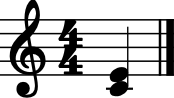

In [19]:
result.show()

In [23]:
result.write('midi', fp=f'twosum_hashset.mid')

'twosum_hashset.mid'

In [21]:
result.show('midi')

In [26]:
melody = [60, 62, 64, 65, 67]

 # Create a new Stream for this melody
score_hs = stream.Stream()
    
    # Convert MIDI numbers to Note objects and add to stream
for num in melody:
    n = note.Note(num)
    n.quarterLength = 1.0  # Set duration (1.0 = quarter note)
    score_hs.append(n)
    
    # Write to a MIDI file
score_hs.write('midi', fp=f'melodyforhashset.mid')


'melodyforhashset.mid'

In [27]:
score_hs.show('text')

{0.0} <music21.note.Note C>
{1.0} <music21.note.Note D>
{2.0} <music21.note.Note E>
{3.0} <music21.note.Note F>
{4.0} <music21.note.Note G>


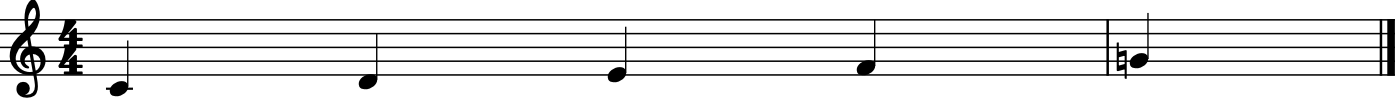

In [28]:
score_hs.show()

In [29]:
score_hs.show('midi')

## Complexity Comparison Table

In [ ]:
#pip install pandas

In [25]:
import pandas as pd

comparison_data = {
    'Approach': [
        '1. Brute Force',
        '2. Sort + Binary Search',
        '3. Sort + Two Pointers',
        '4. Hash Set ⭐'
    ],
    'Time Complexity': ['O(n²)', 'O(n log n)', 'O(n log n)', 'O(n)'],
    'Space Complexity': ['O(1)', 'O(1)', 'O(1)', 'O(n)'],
    'Pros': [
        'Simple to understand',
        'Fast sorting',
        'Elegant & intuitive',
        'Best time complexity!'
    ],
    'Cons': [
        'Very slow for large arrays',
        'Complex code',
        'Requires sorting',
        'Uses extra memory'
    ],
    'Musical Metaphor': [
        'Trying all chords',
        'Systematic search',
        'Two hands converging',
        'Perfect pitch memory'
    ]
}

df = pd.DataFrame(comparison_data)
print(df.to_string(index=False))

               Approach Time Complexity Space Complexity                  Pros                       Cons     Musical Metaphor
         1. Brute Force           O(n²)             O(1)  Simple to understand Very slow for large arrays    Trying all chords
2. Sort + Binary Search      O(n log n)             O(1)          Fast sorting               Complex code    Systematic search
 3. Sort + Two Pointers      O(n log n)             O(1)   Elegant & intuitive           Requires sorting Two hands converging
          4. Hash Set ⭐            O(n)             O(n) Best time complexity!          Uses extra memory Perfect pitch memory


## Summary & Key Takeaways

### Why Use Each Approach?

1. **Brute Force** - Learning algorithm fundamentals
2. **Binary Search** - When you need to understand search algorithms
3. **Two Pointers** - Most interview-friendly; elegant solution
4. **Hash Set** - Production code; optimal time complexity

### Musical Insight
Just like finding harmonic pairs, solving algorithms has multiple valid approaches with different tradeoffs. The best solution depends on your constraints (time vs. space).

### Interval Examples for Musical Thinking
- **2 semitones** = Major 2nd (Do-Re)
- **4 semitones** = Major 3rd (Do-Mi)
- **5 semitones** = Perfect 4th (Do-Fa)
- **7 semitones** = Perfect 5th (Do-Sol) ← Most common!
- **12 semitones** = Octave (Do-Do')